# Modelagem Preditiva da Satisfação do Cliente

Este notebook apresenta a construção de uma solução de Machine Learning voltada à identificação de clientes com maior risco de insatisfação.

A proposta vai além do treinamento de modelos: o objetivo é transformar dados sobre perfil, pedido, entrega e atendimento em informações capazes de apoiar decisões de retenção no e-commerce.

Ao longo do notebook serão desenvolvidas as seguintes etapas:

* definição da variável-alvo;
* criação de atributos derivados;
* divisão entre treino e teste;
* pré-processamento dos dados;
* aplicação de método Filter para verificação de features com baixa variabilidade;
* comparação de diferentes algoritmos;
* otimização de hiperparâmetros;
* validação e comparação dos modelos;
* análise da importância das features;
* avaliação e seleção do modelo final;
* transformação das previsões em ações de negócio.

Na etapa de Feature Selection, será utilizado o método `VarianceThreshold` após o pré-processamento, com o objetivo de identificar possíveis variáveis constantes ou com baixa variabilidade antes do treinamento dos modelos.

Como a base apresenta desbalanceamento entre as classes, a avaliação será orientada por métricas que consideram o desempenho global e o equilíbrio entre os grupos, como F1 Macro, balanced accuracy, recall e matriz de confusão.

> O resultado esperado é uma solução capaz não apenas de prever clientes detratores, mas também de apoiar a priorização de atendimentos, estratégias de recuperação e decisões orientadas por risco.


# 1. Preparação do ambiente

Nesta etapa serão importadas as bibliotecas utilizadas para manipulação dos dados, pré-processamento, treinamento, avaliação e salvamento dos modelos.

In [1]:
# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Salvamento de modelos
# ================================
import joblib

# ================================
# Divisão dos dados
# ================================
from sklearn.model_selection import train_test_split

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ================================
# Validação e otimização
# ================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate, StratifiedKFold

# 2. Leitura da base tratada

Nesta etapa será carregada a base preparada no notebook de entendimento e tratamento dos dados.

Como as etapas de limpeza, tradução das colunas, verificação de valores ausentes, análise de duplicidades e seleção inicial de variáveis já foram realizadas anteriormente, este notebook utilizará diretamente a versão tratada da base.

Após o carregamento, serão exibidas as primeiras observações para confirmar que o arquivo foi lido corretamente.

In [2]:
dados = pd.read_csv('/content/clientes_tratados.csv')
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


# 3. Validação rápida dos dados

Antes de iniciar a modelagem, será realizada uma verificação rápida da base para confirmar se sua estrutura permanece consistente após o processo de tratamento.

Nesta etapa serão conferidos:

- a quantidade de registros e variáveis;
- os tipos das colunas;
- a presença de valores ausentes;
- a existência de registros duplicados.

Essa validação funciona como um controle de qualidade antes da criação das features e do treinamento dos modelos.

In [3]:
print(f'Total de linhas: {dados.shape[0]}')
print(f'Total de colunas: {dados.shape[1]}')

Total de linhas: 2500
Total de colunas: 15


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade_cliente         2500 non-null   int64  
 1   regiao_cliente        2500 non-null   object 
 2   tempo_cliente_meses   2500 non-null   int64  
 3   valor_pedido          2500 non-null   float64
 4   quantidade_itens      2500 non-null   int64  
 5   valor_desconto        2500 non-null   float64
 6   parcelas_pagamento    2500 non-null   int64  
 7   tempo_entrega_dias    2500 non-null   int64  
 8   atraso_entrega_dias   2500 non-null   int64  
 9   valor_frete           2500 non-null   float64
 10  tentativas_entrega    2500 non-null   int64  
 11  contatos_atendimento  2500 non-null   int64  
 12  tempo_resolucao_dias  2500 non-null   int64  
 13  nps                   2500 non-null   float64
 14  numero_reclamacoes    2500 non-null   int64  
dtypes: float64(4), int64(

In [5]:
print(f'Valores Ausentes: {dados.isna().sum().sum()}')
print(f'Valores Duplicados: {dados.duplicated().sum()}')

Valores Ausentes: 0
Valores Duplicados: 0


# 4. Definição da variável-alvo

Nesta etapa, a nota de NPS será transformada em uma variável binária para representar o risco de insatisfação do cliente.

A classificação será definida da seguinte forma:

- `1`: cliente detrator, com nota de NPS entre 0 e 6;
- `0`: cliente não detrator, com nota de NPS acima de 6.

Essa transformação permite tratar o problema como uma tarefa de classificação binária, na qual o objetivo será identificar clientes com maior probabilidade de insatisfação.

In [6]:
# transformando em 0 e 1 - valores 1 representam os detratores
dados['target'] = pd.cut(dados['nps'],
                         bins=[-1, 6., np.inf],
                         labels=[1, 0])

In [7]:
dados['target'].value_counts()

,count
target,
1,1851
0,649


In [8]:
# Fazendo o drop do nps agora, já que iremos utilizar a target
dados = dados.drop('nps', axis=1)

# 5. Engenharia de atributos

Com base nos padrões identificados durante a análise exploratória, serão criadas novas variáveis para representar situações críticas na experiência do cliente.

As variáveis derivadas são:

- `atraso_critico`: indica atrasos iguais ou superiores a 2 dias;
- `problema_complexo`: identifica situações com pelo menos 2 contatos com o atendimento e tempo de resolução igual ou superior a 3 dias;
- `reclamacao_recorrente`: indica clientes com 3 ou mais reclamações.

Essas novas features resumem comportamentos relevantes e poderão ajudar os modelos a identificar padrões associados à insatisfação.

In [9]:
dados['atraso_critico'] = (dados['atraso_entrega_dias'] >= 2).astype(int)

dados['problema_complexo'] = (
    (dados['contatos_atendimento'] >= 2) &
    (dados['tempo_resolucao_dias'] >= 3)
).astype(int)

dados['reclamacao_recorrente'] = (dados['numero_reclamacoes'] >= 3).astype(int)

In [10]:
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,target,atraso_critico,problema_complexo,reclamacao_recorrente
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3,0,1,0,1
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3,1,1,0,1
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7,1,0,1,1
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4,1,1,0,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3,0,0,0,1


# 6. Divisão dos dados em treino e teste

Nesta etapa, o conjunto de dados será separado entre variáveis explicativas e variável-alvo.

- `X`: contém as variáveis utilizadas pelos modelos;
- `y`: contém a variável `target`, que indica se o cliente é detrator.

Em seguida, os dados serão divididos em conjuntos de treino e teste.

O conjunto de treino será utilizado para ajustar os modelos, enquanto o conjunto de teste será reservado para a avaliação final.

A divisão será estratificada pela variável-alvo, preservando a proporção de clientes detratores e não detratores nos dois conjuntos.

In [11]:
X = dados.drop('target', axis=1)
y = dados['target']

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

In [13]:
print(f'Treino: {X_treino.shape[0]}')
print(f'Teste: {X_teste.shape[0]}')

Treino: 2000
Teste: 500


In [14]:
colunas_entrada = X_treino.columns

In [15]:
df = X_teste.copy()

# 7. Pré-processamento dos dados

Nesta etapa, as variáveis serão preparadas para o treinamento dos modelos.

As colunas numéricas serão padronizadas com `StandardScaler`, enquanto a variável categórica `regiao_cliente` será transformada por meio de One-Hot Encoding.

A padronização é importante para modelos sensíveis à escala, como Regressão Logística, KNN e SVM. Já o One-Hot Encoding converte categorias textuais em colunas numéricas, permitindo seu uso pelos algoritmos.

O pré-processador será ajustado somente com os dados de treino e depois aplicado ao conjunto de teste, evitando vazamento de informações.

In [16]:
col_numericas = ['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias',
             'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente']
col_categoricas = ['regiao_cliente']

In [17]:
full_pipeline = ColumnTransformer([
    ("num", StandardScaler(), col_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False), col_categoricas)
])

In [18]:
x_treino_tratado = full_pipeline.fit_transform(X_treino)
x_teste_tratado = full_pipeline.transform(X_teste)

In [19]:
num_cols = list(col_numericas)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(col_categoricas)

X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

In [20]:
X_treino.head()

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente,regiao_cliente_Nordeste,regiao_cliente_Norte,regiao_cliente_Sudeste,regiao_cliente_Sul
0,-1.228616,-1.060464,-0.323005,-1.465588,0.012322,-1.582239,-1.081564,1.231576,-2.031869,-1.231045,-0.422476,-0.727218,-0.652053,0.745124,-0.730577,0.449359,0.0,0.0,0.0,1.0
1,0.911306,-0.275312,2.674934,0.315199,-0.949631,-0.625336,1.580419,0.550771,0.343444,-1.231045,1.215029,-0.436156,1.040859,0.745124,1.368782,0.449359,0.0,0.0,0.0,1.0
2,1.045051,0.335362,0.985016,0.315199,-0.814828,0.012599,-0.549167,-1.491644,-1.062387,-1.231045,2.033782,0.437030,2.169466,-1.342058,1.368782,0.449359,1.0,0.0,0.0,0.0
3,-0.225528,0.975115,-0.569380,-1.465588,0.345084,1.607438,-0.549167,-0.130034,-1.414255,1.222458,-0.422476,-0.727218,-1.216357,0.745124,-0.730577,-2.225395,0.0,0.0,0.0,1.0
4,-0.961126,-0.478870,-0.190397,0.908795,-0.289201,-0.306368,1.580419,1.231576,0.326220,-0.004294,-0.422476,-1.309342,-0.087749,0.745124,-0.730577,0.449359,0.0,0.0,1.0,0.0


# 8. Aplicação do VarianceThreshold

Após o pré-processamento dos dados, foi aplicado o método `VarianceThreshold` com o objetivo de verificar a existência de features com baixa variabilidade.

Como as variáveis categóricas já haviam sido transformadas em valores numéricos pelo `OneHotEncoder`, tornou-se possível aplicar o método diretamente sobre o conjunto tratado.

Foi utilizado o parâmetro `threshold=0.1`, responsável por remover features cuja variância esteja abaixo desse limite.

O método foi ajustado apenas com os dados de treino e, posteriormente, aplicado ao conjunto de teste, mantendo o mesmo padrão de transformação e evitando vazamento de informação.


In [21]:
from sklearn.feature_selection import VarianceThreshold

selector_variance = VarianceThreshold(threshold=0.1)

X_treino_variance = selector_variance.fit_transform(X_treino)
X_teste_variance = selector_variance.transform(X_teste)

features_variance = X_treino.columns[selector_variance.get_support()]

print(f'Features Originais : {X_treino.shape[1]}')
print(f'Features Selecionadas: {len(features_variance)}')

print('\nFeatures Mantidas:')
print(features_variance.tolist())

Features Originais : 20
Features Selecionadas: 20

Features Mantidas:
['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias', 'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente', 'regiao_cliente_Nordeste', 'regiao_cliente_Norte', 'regiao_cliente_Sudeste', 'regiao_cliente_Sul']


### Interpretação

O conjunto possuía inicialmente 20 features e, após a aplicação do `VarianceThreshold`, todas as 20 foram mantidas.

Esse resultado indica que nenhuma das variáveis apresentou variância inferior ao limite definido de `0.1`.

Portanto, não foram identificadas features com baixa variabilidade suficiente para justificar sua remoção nessa etapa.

Dessa forma, todas as variáveis foram preservadas para as próximas etapas de modelagem e seleção de atributos.


# 9. Treinamento e comparação inicial dos modelos

Nesta etapa, diferentes algoritmos de classificação serão treinados utilizando os mesmos conjuntos de treino e teste.

Foram selecionados modelos com características distintas:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- K-Nearest Neighbors;
- Support Vector Machine;
- Naive Bayes;
- XGBoost.

O objetivo desta comparação inicial é identificar quais algoritmos apresentam melhor desempenho na classificação de clientes detratores e não detratores.

Como a base apresenta desbalanceamento entre as classes, a análise não será baseada somente na acurácia. Também serão avaliadas precision, recall e F1-score para cada classe.

In [22]:
modelos_classificacao = {
    "Regressão Logística": LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced"),

    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced",
        n_jobs=-1),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(random_state=42)
}

In [23]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, pred),
        "Precision_0": precision_score(y_teste, pred, pos_label=0),
        "Precision_1": precision_score(y_teste, pred, pos_label=1),
        "Recall_0": recall_score(y_teste, pred, pos_label=0),
        "Recall_1": recall_score(y_teste, pred, pos_label=1),
        "F1-score": f1_score(y_teste, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)
print("====== Resultados dos Modelos Ordenados por F1-Score ======\n")
resultados_df.round(3)

====== Resultados dos Modelos Ordenados por F1-Score ======



,Modelo,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1-score
2,Random Forest,0.838,0.743,0.862,0.577,0.930,0.895
6,XGBoost,0.818,0.689,0.851,0.546,0.914,0.881
3,KNN,0.800,0.647,0.839,0.508,0.903,0.870
5,Naive Bayes,0.808,0.620,0.883,0.677,0.854,0.868
1,Árvore de Decisão,0.778,0.586,0.833,0.500,0.876,0.854
0,Regressão Logística,0.798,0.580,0.922,0.808,0.795,0.853
4,SVM,0.794,0.574,0.921,0.808,0.789,0.850


In [24]:
# Selecionando o top3 modelos
for nome in['Random Forest', 'XGBoost', 'KNN']:
  modelo = modelos_classificacao[nome]
  modelo.fit(X_treino, y_treino)
  pred = modelo.predict(X_teste)

  print(f'\n\nModelo: {nome}')
  print(classification_report(y_teste, pred))



Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.74      0.58      0.65       130
           1       0.86      0.93      0.89       370

    accuracy                           0.84       500
   macro avg       0.80      0.75      0.77       500
weighted avg       0.83      0.84      0.83       500



Modelo: XGBoost
              precision    recall  f1-score   support

           0       0.69      0.55      0.61       130
           1       0.85      0.91      0.88       370

    accuracy                           0.82       500
   macro avg       0.77      0.73      0.75       500
weighted avg       0.81      0.82      0.81       500



Modelo: KNN
              precision    recall  f1-score   support

           0       0.65      0.51      0.57       130
           1       0.84      0.90      0.87       370

    accuracy                           0.80       500
   macro avg       0.74      0.71      0.72       500
weighted avg      

### Comparação inicial dos modelos

O **Random Forest** apresentou o melhor desempenho inicial, com acurácia de aproximadamente **84%**, seguido pelo **XGBoost**, com cerca de **82%**. Ambos também obtiveram bons valores de recall para a classe positiva.

O **KNN** apresentou desempenho inferior, principalmente na identificação da classe 0, indicando maior dificuldade em reconhecer corretamente esse grupo.

De forma geral, **Random Forest e XGBoost** se destacaram como os modelos mais promissores para as próximas etapas.

Como a base apresenta desbalanceamento entre as classes, a seleção dos modelos não será baseada apenas na acurácia. Também serão consideradas métricas como **F1 Macro**, **balanced accuracy** e **recall por classe**.


# 10. Otimização de hiperparâmetros

Após a comparação inicial dos algoritmos, foram selecionados XGBoost, Random Forest e KNN para a etapa de otimização.

O objetivo é buscar combinações de hiperparâmetros capazes de melhorar o desempenho e a capacidade de generalização dos modelos.

A otimização será realizada com `RandomizedSearchCV`, utilizando validação cruzada com cinco divisões e F1 Macro como métrica principal, já que essa métrica considera o desempenho das duas classes de forma equilibrada.

In [25]:
# Modelos a serem utilizados
xgb_model = XGBClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

knn_model = KNeighborsClassifier()

### Espaços de busca

Para cada algoritmo, foram definidos conjuntos de hiperparâmetros relacionados à complexidade, regularização e comportamento do modelo.

O `RandomizedSearchCV` testará diferentes combinações dentro desses espaços, reduzindo o custo computacional em comparação com uma busca exaustiva.

In [26]:
# Params XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5, 1],
    # Regularização L1
    "reg_alpha": [0, 0.01, 0.1, 1],
    # Regularização L2
    "reg_lambda": [0.1, 1, 5, 10]
}
# Params Random Forest
param_dist_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True, False]
}
# Parâmetros do KNN
param_dist_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

In [27]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

### Execução da otimização

As buscas serão ajustadas utilizando apenas o conjunto de treino.

Ao final, será selecionada a combinação de hiperparâmetros que apresentar o melhor desempenho médio durante a validação cruzada.

In [28]:
random_xgb.fit(X_treino, y_treino)
random_rf.fit(X_treino, y_treino)
random_knn.fit(X_treino, y_treino)

print("XGBoost - melhores parâmetros:")
print(random_xgb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("KNN - melhores parâmetros:")
print(random_knn.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBoost - melhores parâmetros:
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}

Random Forest - melhores parâmetros:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}

KNN - melhores parâmetros:
{'weights': 'distance', 'n_neighbors': 7, 'metric': 'euclidean'}



### Avaliação dos modelos otimizados

Após a otimização, os melhores estimadores serão avaliados no conjunto de teste.

Serão analisadas métricas como acurácia, precision, recall e F1-score para cada classe.

Nesta etapa, os resultados serão apenas registrados. A escolha do modelo final será realizada posteriormente, após a comparação visual apresentada na próxima seção.

In [29]:
modelos_tunados = {
    "XGBoost Tunado": random_xgb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "KNN Tunado": random_knn.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_teste)

    resultados_tuning.append({
      'Modelo': nome,
      'Acurácia': accuracy_score(y_teste, pred),
      'Recall_0': recall_score(y_teste, pred, pos_label=0),
      'Recall_1': recall_score(y_teste, pred, pos_label=1),
      'Precision_0': precision_score(y_teste, pred, pos_label=0),
      'Precision_1': precision_score(y_teste, pred, pos_label=1),
      'F1-Score': f1_score(y_teste, pred)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(
    by="F1-Score", ascending=False
)

resultados_tuning_df.round(4)

,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
0,XGBoost Tunado,0.830,0.5615,0.9243,0.7228,0.8571,0.8895
1,Random Forest Tunado,0.834,0.6769,0.8892,0.6822,0.8868,0.8880
2,KNN Tunado,0.800,0.5154,0.9000,0.6442,0.8409,0.8695


In [30]:
for nome in ["XGBoost Tunado", "Random Forest Tunado", "KNN Tunado"]:
    modelo = modelos_tunados[nome]
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    print(f"\n=== {nome} ===")
    print(classification_report(y_teste, pred))


=== XGBoost Tunado ===
              precision    recall  f1-score   support

           0       0.72      0.56      0.63       130
           1       0.86      0.92      0.89       370

    accuracy                           0.83       500
   macro avg       0.79      0.74      0.76       500
weighted avg       0.82      0.83      0.82       500


=== Random Forest Tunado ===
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       130
           1       0.89      0.89      0.89       370

    accuracy                           0.83       500
   macro avg       0.78      0.78      0.78       500
weighted avg       0.83      0.83      0.83       500


=== KNN Tunado ===
              precision    recall  f1-score   support

           0       0.64      0.52      0.57       130
           1       0.84      0.90      0.87       370

    accuracy                           0.80       500
   macro avg       0.74      0.71      0.72       500


### Síntese da otimização

A otimização gerou versões ajustadas dos modelos XGBoost, Random Forest e KNN.

Os resultados mostram diferenças no equilíbrio entre a identificação das classes `0` e `1`, mas ainda não será realizada a escolha definitiva do modelo.

Na próxima etapa, as métricas serão comparadas visualmente para apoiar uma decisão mais clara e fundamentada.

# 11. Análise gráfica dos modelos otimizados

Nesta etapa, os modelos otimizados serão comparados por meio das matrizes de confusão e das curvas ROC.

As matrizes de confusão permitem observar como cada algoritmo classificou as classes `0` e `1`, enquanto a curva ROC avalia a capacidade de separação entre clientes detratores e não detratores em diferentes limiares de decisão.

A análise conjunta dessas visualizações será utilizada para apoiar a escolha do modelo final.

## Matrizes de confusão

As matrizes de confusão mostram os acertos e erros de classificação de cada modelo.

Neste projeto:

- `0` representa clientes não detratores;
- `1` representa clientes detratores.

Além do total de acertos, será observado o equilíbrio entre a identificação das duas classes.

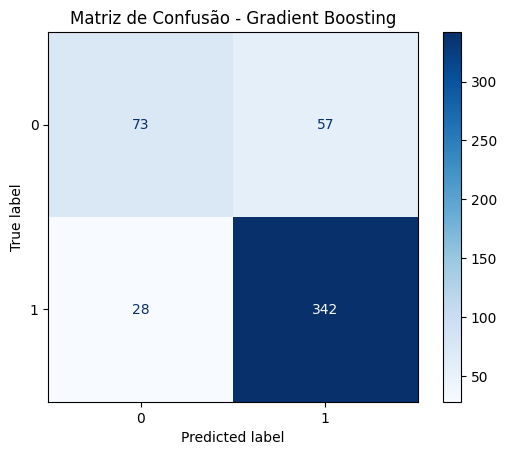

In [51]:
modelo_xgb_final = random_xgb.best_estimator_

ConfusionMatrixDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Gradient Boosting')
plt.show()

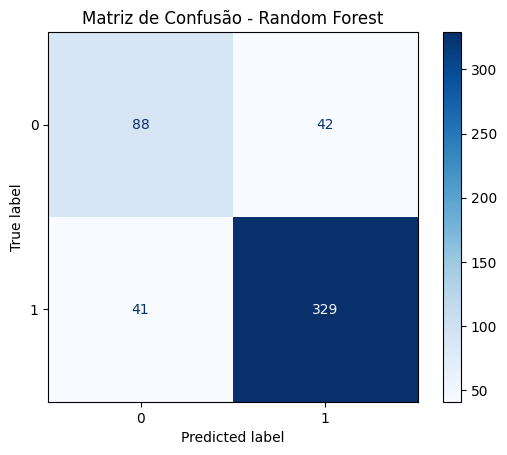

In [52]:
modelo_rf_final = random_rf.best_estimator_

ConfusionMatrixDisplay.from_estimator(modelo_rf_final, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

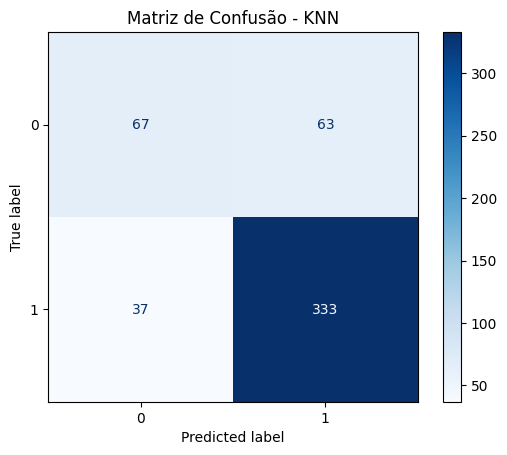

In [53]:
modelo_knn_final = random_knn.best_estimator_

ConfusionMatrixDisplay.from_estimator(modelo_knn_final, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - KNN')
plt.show()

### Interpretação das matrizes de confusão

O **XGBoost** classificou corretamente **73 clientes da classe 0** e **342 da classe 1**, apresentando boa capacidade de identificar a classe positiva, embora ainda tenha classificado **57 clientes da classe 0 como classe 1**.

O **Random Forest** apresentou o melhor equilíbrio entre as duas classes, identificando corretamente **88 clientes da classe 0** e **329 da classe 1**.

O **KNN** classificou corretamente **333 clientes da classe 1**, porém apresentou maior dificuldade na classe 0, com **63 classificações incorretas**.

De forma geral, o **XGBoost** apresentou maior sensibilidade para a classe positiva, enquanto o **Random Forest** demonstrou comportamento mais equilibrado entre as duas classes.


## Curvas ROC

A curva ROC representa a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos em diferentes limites de classificação.

A área sob a curva, conhecida como AUC, varia entre 0 e 1. Quanto maior o valor, maior a capacidade do modelo de diferenciar as duas classes.

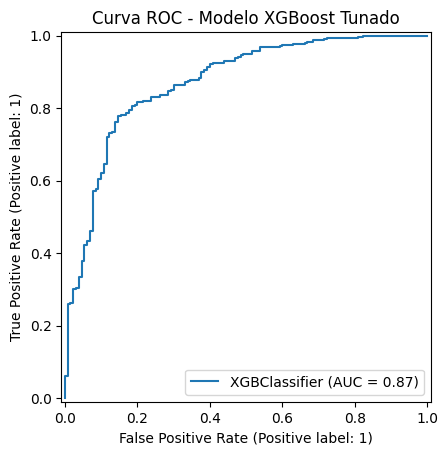

In [54]:
RocCurveDisplay.from_estimator(modelo_xgb_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo XGBoost Tunado")
plt.show()

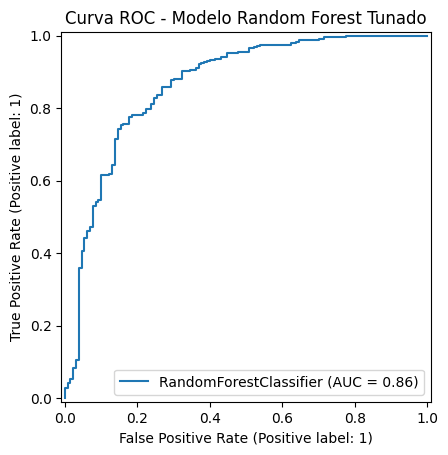

In [35]:
RocCurveDisplay.from_estimator(modelo_rf_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo Random Forest Tunado")
plt.show()

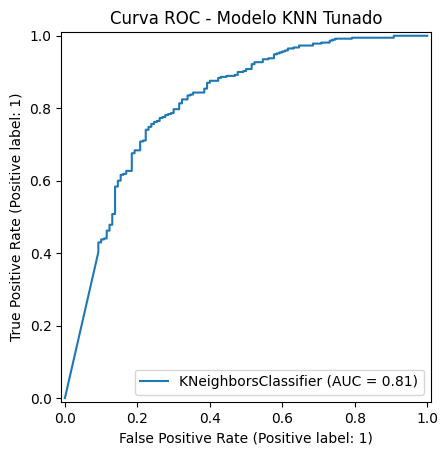

In [36]:
RocCurveDisplay.from_estimator(modelo_knn_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo KNN Tunado")
plt.show()

### Interpretação das curvas ROC

O **XGBoost** apresentou o melhor desempenho na curva ROC, com **AUC de aproximadamente 0,87**, seguido pelo **Random Forest**, com **0,86**.

O **KNN** apresentou AUC de aproximadamente **0,81**, resultado inferior aos demais modelos, embora ainda demonstre capacidade de discriminação entre as classes.

De forma geral, **XGBoost e Random Forest** apresentaram melhor capacidade de separação global entre clientes detratores e não detratores.


### Seleção do modelo final

Após a análise conjunta das métricas, matrizes de confusão e curvas ROC, o **XGBoost** foi selecionado como modelo final.

O modelo apresentou **AUC de aproximadamente 0,87**, boa capacidade de identificação da classe positiva e desempenho consistente nas etapas de avaliação.

Embora o Random Forest tenha apresentado maior equilíbrio entre as classes, o XGBoost foi priorizado por sua maior capacidade de discriminação global e pelo desempenho obtido após o ajuste de hiperparâmetros.

A escolha também considera o contexto do projeto, em que identificar corretamente clientes com maior risco de insatisfação é essencial para apoiar ações de retenção e recuperação.


# 12. Validação cruzada do modelo final

Após a seleção do XGBoost como modelo final, será realizada uma validação cruzada estratificada com cinco divisões.

O objetivo é verificar se o desempenho do modelo permanece consistente em diferentes subconjuntos dos dados de treino, reduzindo a dependência de uma única divisão entre treino e teste.

Serão avaliadas as métricas de acurácia, precision, recall, F1-score e ROC-AUC.

In [37]:
modelo_final = random_xgb.best_estimator_

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_resultados = cross_validate(
    estimator=modelo_final,
    X = X_treino,
    y = y_treino,
    cv= cv,
    scoring= metricas,
    n_jobs= -1
)

In [38]:
# Organizando resultados
cv_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Média': [
        cv_resultados['test_accuracy'].mean(),
        cv_resultados['test_precision'].mean(),
        cv_resultados['test_recall'].mean(),
        cv_resultados['test_f1'].mean(),
        cv_resultados['test_roc_auc'].mean()
    ],
    'Desvio padrão': [
        cv_resultados['test_accuracy'].std(),
        cv_resultados['test_precision'].std(),
        cv_resultados['test_recall'].std(),
        cv_resultados['test_f1'].std(),
        cv_resultados['test_roc_auc'].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.8300,0.0135
1,Precision,0.8560,0.0124
2,Recall,0.9264,0.0073
3,F1-score,0.8898,0.0083
4,ROC-AUC,0.8734,0.0171


### Interpretação

O **XGBoost** apresentou desempenho consistente durante a validação cruzada.

A acurácia média foi de **83,0%**, enquanto o recall médio alcançou **92,64%**, indicando boa capacidade de identificar clientes da classe positiva.

O modelo também apresentou **F1-score médio de 88,98%** e **ROC-AUC média de 87,34%**, reforçando sua boa capacidade de classificação e separação entre as classes.

Os baixos desvios-padrão observados nas métricas indicam comportamento estável entre as diferentes divisões dos dados, reforçando a escolha do XGBoost como modelo final do projeto.


# 13. Feature Importance - Modelo XGBoost

Após a seleção e avaliação dos modelos, foi analisada a importância das features no modelo XGBoost final.

O objetivo dessa etapa é identificar quais variáveis tiveram maior contribuição para as decisões do modelo, permitindo entender melhor quais fatores estão mais associados às previsões realizadas.

As importâncias foram extraídas por meio do atributo `feature_importances_` e organizadas em ordem decrescente, destacando as 10 variáveis mais relevantes.


In [39]:
importance_xgb = pd.DataFrame({
    "feature": X_treino.columns,
    "importance": modelo_xgb_final.feature_importances_
})

importance_xgb = importance_xgb.sort_values("importance", ascending=False)

importance_xgb.head(10)

,feature,importance
15,reclamacao_recorrente,0.338289
12,numero_reclamacoes,0.143761
7,atraso_entrega_dias,0.110012
13,atraso_critico,0.098193
10,contatos_atendimento,0.046429
11,tempo_resolucao_dias,0.043666
16,regiao_cliente_Nordeste,0.028523
19,regiao_cliente_Sul,0.027895
9,tentativas_entrega,0.020925
17,regiao_cliente_Norte,0.018435


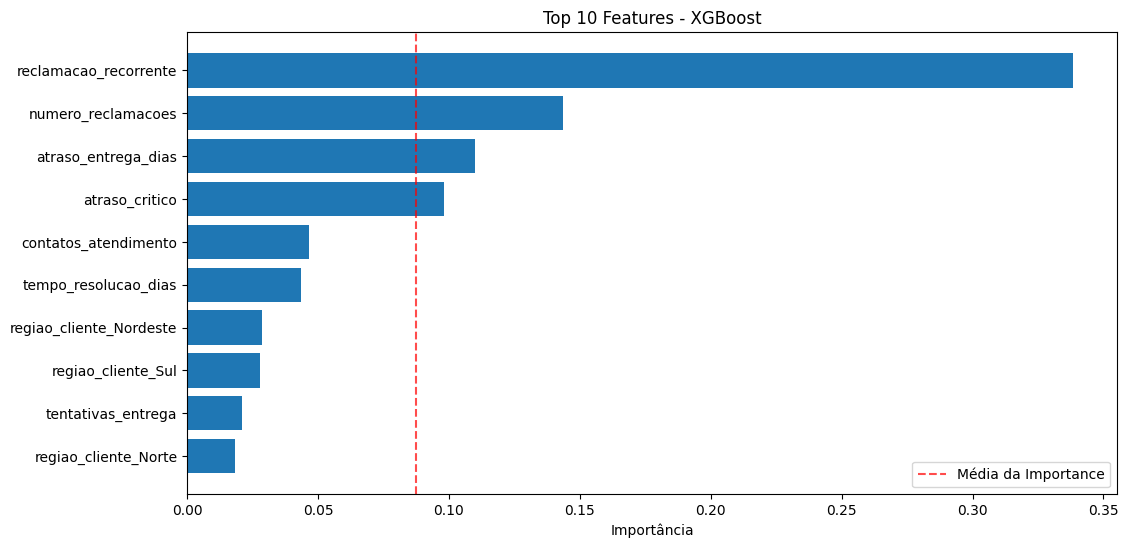

In [40]:
top_10_xgb = importance_xgb.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_10_xgb["feature"], top_10_xgb["importance"])
plt.axvline(top_10_xgb["importance"].mean(), color='red', linestyle='--', alpha=0.7, label='Média da Importance')

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.title("Top 10 Features - XGBoost")
plt.legend()

plt.show()

### Interpretação

A variável `reclamacao_recorrente` apresentou a maior importância no modelo, com valor aproximado de `0.34`, destacando-se de forma expressiva em relação às demais features.

Na sequência, aparecem `numero_reclamacoes`, `atraso_entrega_dias` e `atraso_critico`, indicando que fatores relacionados à recorrência de reclamações e atrasos tiveram forte influência nas previsões realizadas pelo XGBoost.

Também apresentaram contribuição relevante as variáveis `contatos_atendimento` e `tempo_resolucao_dias`.

De forma geral, o ranking reforça os padrões observados durante a análise exploratória, em que problemas relacionados a reclamações, atrasos e atendimento apresentaram forte associação com a satisfação dos clientes.


# 14. Aplicação do modelo ao negócio

Após a validação do modelo final, as probabilidades previstas serão utilizadas para transformar o resultado técnico em informações acionáveis para o e-commerce.

O objetivo desta etapa é identificar clientes com maior risco de insatisfação, priorizar os casos com maior impacto financeiro e recomendar ações de retenção de acordo com os problemas observados na jornada.

In [41]:
dados_resultado = df.copy()

In [42]:
# Gerando a probabilidade do cliente ser detrator
dados_resultado["prob_detrator"] = (
    modelo_final.predict_proba(X_teste)[:, 1]
)

### Segmentação por nível de risco

Os clientes serão agrupados em quatro níveis de risco com base na probabilidade prevista pelo modelo:

- **Baixo:** até 30%;
- **Moderado:** entre 30% e 60%;
- **Alto:** entre 60% e 80%;
- **Crítico:** acima de 80%.

Essa segmentação facilita a definição de diferentes estratégias de acompanhamento e retenção.

In [43]:
dados_resultado["nivel_risco"] = pd.cut(
    dados_resultado["prob_detrator"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=[
        "Baixo",
        "Moderado",
        "Alto",
        "Crítico"
    ],
    include_lowest=True
)

### Identificação dos problemas críticos

Além do nível de risco, serão consideradas três situações críticas identificadas durante a análise exploratória:

- atraso crítico na entrega;
- problema complexo de atendimento;
- reclamação recorrente.

A quantidade de problemas enfrentados por cada cliente será utilizada para tornar a recomendação de ação mais específica.

In [44]:
colunas_problemas = [
    "atraso_critico",
    "problema_complexo",
    "reclamacao_recorrente"
]

dados_resultado["quantidade_problemas"] = (
    dados_resultado[colunas_problemas]
    .sum(axis=1)
)

### Priorização financeira

O indicador `valor_em_risco` combina a probabilidade de o cliente ser detrator com o valor do pedido.

Essa medida funciona como um índice de priorização, destacando clientes que apresentam simultaneamente maior risco de insatisfação e maior relevância financeira.

O valor calculado não representa uma perda financeira garantida, mas uma referência para apoiar a ordem de atendimento.

In [45]:
dados_resultado["valor_em_risco"] = (
    dados_resultado["prob_detrator"]
    * dados_resultado["valor_pedido"]
).round(2)

### Recomendação de ações

As ações recomendadas serão definidas com base na combinação entre o nível de risco e os problemas críticos identificados na jornada.

Clientes com múltiplos problemas receberão ações mais completas e prioritárias, enquanto clientes com risco moderado ou baixo poderão ser acompanhados por estratégias de monitoramento e relacionamento.

In [46]:
def recomendar_acao(linha):
    atraso = linha["atraso_critico"] == 1
    problema = linha["problema_complexo"] == 1
    reclamacao = linha["reclamacao_recorrente"] == 1
    risco = linha["nivel_risco"]

    if atraso and problema and reclamacao:
        return "Atendimento sênior e plano completo de recuperação"

    if reclamacao and problema:
        return "Atendimento especializado e acompanhamento até a resolução"

    if atraso and reclamacao:
        return "Contato prioritário e compensação pela falha logística"

    if atraso and problema:
        return "Atendimento especializado e acompanhamento da entrega"

    if reclamacao:
        return "Analisar a causa recorrente e realizar contato prioritário"

    if atraso:
        return "Pedido de desculpas e benefício no próximo frete"

    if problema:
        return "Encaminhar para atendimento especializado"

    if risco == "Crítico":
        return "Contato preventivo imediato"

    if risco == "Alto":
        return "Acompanhamento preventivo"

    if risco == "Moderado":
        return "Monitoramento ativo e comunicação de relacionamento"

    if risco == "Baixo":
        return "Monitoramento padrão"

    return "Revisar classificação"

In [47]:
dados_resultado["acao_recomendada"] = (
    dados_resultado.apply(
        recomendar_acao,
        axis=1
    )
)

### Sugestão de desconto

O valor do desconto sugerido será calculado a partir do valor em risco.

Para evitar recomendações excessivas, será aplicado um limite máximo de R$ 80,00 por cliente.

Esse valor representa uma simulação para o projeto e, em uma aplicação real, deveria ser validado com base na margem dos produtos, no orçamento disponível e na política comercial da empresa.

In [48]:
dados_resultado["valor_desconto_sugerido"] = (
    dados_resultado["valor_em_risco"] * 0.08
).clip(
    upper=80
).round(2)

### Tabela final de retenção

A tabela final reunirá as principais informações necessárias para apoiar a tomada de decisão:

- probabilidade de o cliente ser detrator;
- nível de risco;
- valor do pedido;
- valor em risco;
- quantidade de problemas críticos;
- ação recomendada;
- desconto sugerido.

Os clientes serão ordenados pela quantidade de problemas e pelo valor em risco, formando uma fila de priorização para as áreas de atendimento e relacionamento.

In [49]:
resultado_retencao = (
    dados_resultado[
        [
            "prob_detrator",
            "nivel_risco",
            "valor_pedido",
            "valor_em_risco",
            "quantidade_problemas",
            "atraso_critico",
            "problema_complexo",
            "reclamacao_recorrente",
            "acao_recomendada",
            "valor_desconto_sugerido"
        ]
    ]
    .sort_values(
        by=[
            "quantidade_problemas",
            "valor_em_risco"
        ],
        ascending=False
    )
)

resultado_retencao.head(5)

,prob_detrator,nivel_risco,valor_pedido,valor_em_risco,quantidade_problemas,atraso_critico,problema_complexo,reclamacao_recorrente,acao_recomendada,valor_desconto_sugerido
986,0.991946,Crítico,1153.70,1144.41,3,1,1,1,Atendimento sênior e plano completo de recuper...,80.00
1466,0.950171,Crítico,1070.81,1017.45,3,1,1,1,Atendimento sênior e plano completo de recuper...,80.00
763,0.899058,Crítico,1094.43,983.96,3,1,1,1,Atendimento sênior e plano completo de recuper...,78.72
1194,0.861445,Crítico,1103.63,950.72,3,1,1,1,Atendimento sênior e plano completo de recuper...,76.06
1673,0.982785,Crítico,927.01,911.05,3,1,1,1,Atendimento sênior e plano completo de recuper...,72.88


# 15. Salvamento do modelo e do pré-processamento

Após a seleção e validação do modelo final, serão salvos os principais artefatos utilizados na solução.

O modelo preditivo será armazenado para permitir novas previsões sem a necessidade de realizar um novo treinamento.

Também será salvo o pipeline de pré-processamento, responsável por aplicar às novas observações as mesmas transformações utilizadas durante a etapa de modelagem.

Esse cuidado garante consistência entre os dados utilizados no treinamento e os dados recebidos posteriormente em produção.

In [50]:
# Salvando o Modelo Preditivo
joblib.dump(modelo_final, 'modelo_final.pkl')

# Salvando o pipeline de pré-processamento
joblib.dump(full_pipeline, 'pre_processamento.pkl')

['pre_processamento.pkl']

## Considerações finais

Este notebook consolidou a etapa de modelagem do projeto, transformando a base tratada em uma solução preditiva voltada à identificação de clientes detratores.

### Principais etapas realizadas

* definição da variável-alvo;
* criação de variáveis derivadas com base nos padrões encontrados na análise exploratória;
* separação entre treino e teste, preservando a distribuição das classes;
* pré-processamento com padronização das variáveis numéricas e codificação da variável categórica;
* verificação de baixa variabilidade com `VarianceThreshold`;
* treinamento e comparação de diferentes algoritmos de classificação;
* otimização de hiperparâmetros com validação cruzada;
* avaliação dos modelos com F1 Macro, relatórios de classificação, matriz de confusão e curva ROC.

Após o pré-processamento, o `VarianceThreshold` foi utilizado como uma etapa de verificação das features com baixa variabilidade. Como nenhuma variável apresentou variância inferior ao limite definido, todas as 20 features foram mantidas para as etapas seguintes.

### Seleção do modelo final

Após a comparação dos modelos e a análise de estabilidade durante a validação cruzada, o `XGBoost` foi selecionado como modelo final.

A escolha considerou:

* desempenho preditivo;
* capacidade de identificar clientes detratores;
* equilíbrio entre as classes;
* estabilidade nas validações;
* possibilidade de interpretação por meio da importância das features.

### Importância das features

A análise de `feature_importances_` do XGBoost mostrou maior relevância para variáveis relacionadas a reclamações, atrasos e atendimento.

Entre as principais features, destacaram-se:

* `reclamacao_recorrente`;
* `numero_reclamacoes`;
* `atraso_entrega_dias`;
* `atraso_critico`;
* `contatos_atendimento`;
* `tempo_resolucao_dias`.

Esses resultados reforçam os padrões observados durante a análise exploratória, indicando que problemas operacionais e recorrência de reclamações possuem forte influência no comportamento preditivo do modelo.

### Aplicação ao negócio

Além da classificação, foi desenvolvida uma camada de aplicação prática utilizando as probabilidades geradas pelo modelo.

Essas probabilidades foram utilizadas para criar:

* níveis de risco;
* indicadores de prioridade financeira;
* recomendações de ação;
* critérios para priorização de clientes com maior probabilidade de insatisfação.

Dessa forma, o modelo pode ser utilizado não apenas para prever clientes detratores, mas também para apoiar ações de retenção, priorização de atendimento e tomada de decisão no contexto do e-commerce.

### Resultado final

Por fim, o modelo XGBoost e o pipeline de pré-processamento foram salvos para reutilização em novas previsões, garantindo consistência entre o treinamento e o uso futuro da solução.

O resultado final é uma solução que integra:

* preparação de dados;
* engenharia de atributos;
* seleção e análise de features;
* Machine Learning;
* validação estatística;
* interpretabilidade;
* aplicação prática ao negócio.
